### Thesis: Process Intelligence with Python Language

# Simple Artificial Example

This notebook demonstrates the core PM4Py workflow on a hand-built toy event log.
The goal is to understand the internal data structures used by the library
before applying them to real datasets.

| Step | Function | PM4Py API |
|------|----------|-----------|
| 1 | Build toy event log | `pd.DataFrame` |
| 2 | Convert to EventLog | `pm4py.convert_to_event_log()` |
| 3 | Inspect structures | `inspect_input_structures()` |
| 4 | Discover Petri net | `pm4py.discover_petri_net_inductive()` |
| 5 | Inspect output | `inspect_output_structures()` |
| 6 | Visualise and export | `pm4py.save_vis_petri_net()` |


### 1. Imports and Config:

In [1]:
# IMPORTS
import os
import shutil
import warnings
import pandas as pd
import pm4py
from IPython.display import Image, display

warnings.filterwarnings("ignore")

OUTPUT_DIR = "output"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("PM4Py version :", pm4py.__version__)
print("Output folder :", os.path.abspath(OUTPUT_DIR))


PM4Py version : 2.7.19.1
Output folder : C:\Users\TRANG\SGH\thesis SGH\thesis prof\output


### 2. Definitions: 

### Task 1 — Build Toy Event Log: 

In [2]:
def build_toy_event_log() -> pd.DataFrame:
    """
    Build a small toy event log as a pandas DataFrame.

    Three cases, one variant:
      All cases: Create order -> Approve order -> Send invoice
    """
    data = [
        # Case 1: Create order -> Approve order -> Send invoice
        {"case_id": "1", "activity": "Create order",  "timestamp": "2024-01-01 09:00:00"},
        {"case_id": "1", "activity": "Approve order", "timestamp": "2024-01-01 10:00:00"},
        {"case_id": "1", "activity": "Send invoice",  "timestamp": "2024-01-01 11:00:00"},

        # Case 2: Create order -> Approve order -> Send invoice
        {"case_id": "2", "activity": "Create order",  "timestamp": "2024-01-02 09:15:00"},
        {"case_id": "2", "activity": "Approve order", "timestamp": "2024-01-02 10:30:00"},
        {"case_id": "2", "activity": "Send invoice",  "timestamp": "2024-01-02 11:20:00"},

        # Case 3: Create order -> Approve order -> Send invoice
        {"case_id": "3", "activity": "Create order",  "timestamp": "2024-01-03 08:45:00"},
        {"case_id": "3", "activity": "Approve order", "timestamp": "2024-01-03 09:50:00"},
        {"case_id": "3", "activity": "Send invoice",  "timestamp": "2024-01-03 10:40:00"},
    ]

    df = pd.DataFrame(data)

    # Rename to XES-style column names (IEEE 1849-2016 standard)
    df = df.rename(columns={
        "case_id":   "case:concept:name",
        "activity":  "concept:name",
        "timestamp": "time:timestamp",
    })
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])
    return df


df_toy = build_toy_event_log()
print(df_toy.to_string())

  case:concept:name   concept:name      time:timestamp
0                 1   Create order 2024-01-01 09:00:00
1                 1  Approve order 2024-01-01 10:00:00
2                 1   Send invoice 2024-01-01 11:00:00
3                 2   Create order 2024-01-02 09:15:00
4                 2  Approve order 2024-01-02 10:30:00
5                 2   Send invoice 2024-01-02 11:20:00
6                 3   Create order 2024-01-03 08:45:00
7                 3  Approve order 2024-01-03 09:50:00
8                 3   Send invoice 2024-01-03 10:40:00



### Note — IEEE 1849-2016 Standard Column Names

PM4Py uses **XES** (eXtensible Event Stream) naming conventions defined by **IEEE 1849-2016**.
Attribute names follow the pattern `prefix:attribute_name`:

| Prefix | Meaning | Example |
|--------|---------|---------|
| `concept:` | Semantic information | `concept:name` (activity label) |
| `time:` | Temporal attribute | `time:timestamp` |
| `org:` | Organisational data | `org:resource` (executor) |
| `lifecycle:` | Lifecycle state | `lifecycle:transition` (`complete`, `start`) |
| `case:` | Trace-level attribute | `case:concept:name` (case / trace ID) |

The `case:` prefix is special: it denotes attributes that belong to the **trace**
(case level) rather than to an individual event.
All other prefixes belong to the **event** level.


### Task 2 — Convert to EventLog


In [5]:
def convert_to_event_log(df: pd.DataFrame):
    """
    Convert a pandas DataFrame into a PM4Py EventLog object.

    Requires columns: case:concept:name, concept:name, time:timestamp.
    pm4py.convert_to_event_log() groups rows into traces (one per case)
    and sorts events within each trace by timestamp.
    """
    return pm4py.convert_to_event_log(df)


event_log = convert_to_event_log(df_toy)

print("Type of event_log :", type(event_log))
print("Number of traces  :", len(event_log))


Type of event_log : <class 'pm4py.objects.log.obj.EventLog'>
Number of traces  : 3


### Inspect public attributes of EventLog


In [7]:
# Public properties of the EventLog object (non-dunder only)
public_props = [p for p in dir(event_log) if not p.startswith("_")]
print(f"Public attributes of {type(event_log).__name__}:")
for p in public_props:
    print(" ", p)

Public attributes of EventLog:
  append
  attributes
  classifiers
  count
  extensions
  index
  omni_present
  properties


### Task 3 — Inspect Input Data Structures


In [9]:
def inspect_input_structures(log) -> None:
    """
    Inspect the data structures used as input to the Inductive Miner.

    Shows the hierarchy: EventLog > Trace > Event (dict)
    """
    print("=== INPUT DATA STRUCTURES ===")
    print("Python type of log          :", type(log))
    print("Number of traces (cases)    :", len(log))

    first_trace = log[0]
    print("\nType of first trace         :", type(first_trace))
    print("Events in first trace       :", len(first_trace))

    first_event = first_trace[0]
    print("\nType of first event         :", type(first_event))
    print("First event (dict)          :", dict(first_event))
    print("Keys                        :", list(first_event.keys()))
    print()
inspect_input_structures(event_log)


=== INPUT DATA STRUCTURES ===
Python type of log          : <class 'pm4py.objects.log.obj.EventLog'>
Number of traces (cases)    : 3

Type of first trace         : <class 'pm4py.objects.log.obj.Trace'>
Events in first trace       : 3

Type of first event         : <class 'pm4py.objects.log.obj.Event'>
First event (dict)          : {'concept:name': 'Create order', 'time:timestamp': Timestamp('2024-01-01 09:00:00')}
Keys                        : ['concept:name', 'time:timestamp']



### Export — DataFrame, Markdown, CSV

Converting the EventLog back to a DataFrame makes it easy to inspect,
export as Markdown (for Typst), or save as CSV for direct inclusion in the document.


In [11]:
# Convert EventLog → DataFrame
df_back = pm4py.convert_to_dataframe(event_log)

print("=== Full DataFrame ===")
print(df_back[["case:concept:name", "concept:name",
               "time:timestamp"]].to_string(index=False))

print("\n=== Markdown table (for Typst) ===")
print(df_back[["case:concept:name", "concept:name",
               "time:timestamp"]].to_markdown(index=False))

# Save as CSV for direct use in Typst  →  #csv("tab_synth_eventlog.csv")
csv_path = os.path.join(OUTPUT_DIR, "tab_synth_eventlog.csv")
df_back[["case:concept:name", "concept:name", "time:timestamp"]].to_csv(
    csv_path, index=False
)
print("\nCSV saved:", csv_path)


=== Full DataFrame ===
case:concept:name  concept:name      time:timestamp
                1  Create order 2024-01-01 09:00:00
                1 Approve order 2024-01-01 10:00:00
                1  Send invoice 2024-01-01 11:00:00
                2  Create order 2024-01-02 09:15:00
                2 Approve order 2024-01-02 10:30:00
                2  Send invoice 2024-01-02 11:20:00
                3  Create order 2024-01-03 08:45:00
                3 Approve order 2024-01-03 09:50:00
                3  Send invoice 2024-01-03 10:40:00

=== Markdown table (for Typst) ===
|   case:concept:name | concept:name   | time:timestamp      |
|--------------------:|:---------------|:--------------------|
|                   1 | Create order   | 2024-01-01 09:00:00 |
|                   1 | Approve order  | 2024-01-01 10:00:00 |
|                   1 | Send invoice   | 2024-01-01 11:00:00 |
|                   2 | Create order   | 2024-01-02 09:15:00 |
|                   2 | Approve order  | 20

### Task 4 — Run Inductive Miner


In [13]:
def run_inductive_miner(log):
    """
    Discover a Petri net from the event log using the Inductive Miner.

    Returns (net, im, fm):
      net  — the discovered Petri net (guaranteed sound: no deadlocks)
      im   — initial marking (tokens in start places)
      fm   — final marking  (tokens in end places)
    """
    net, im, fm = pm4py.discover_petri_net_inductive(log)
    return net, im, fm


net, im, fm = run_inductive_miner(event_log)

print("Type of net :", type(net))
print("Type of im  :", type(im))
print("Type of fm  :", type(fm))

Type of net : <class 'pm4py.objects.petri_net.obj.PetriNet'>
Type of im  : <class 'pm4py.objects.petri_net.obj.Marking'>
Type of fm  : <class 'pm4py.objects.petri_net.obj.Marking'>


### Task 5 — Inspect Output Data Structures


In [15]:
def inspect_output_structures(net, im, fm) -> None:
    """
    Inspect and print the output data structures returned by the Inductive Miner.
    """
    print("=== OUTPUT DATA STRUCTURES ===")
    print("Petri net type     :", type(net))
    print("Initial marking    :", type(im))
    print("Final marking      :", type(fm))

    print("\n=== PETRI NET SUMMARY ===")
    print("Places     :", len(net.places))
    print("Transitions:", len(net.transitions))
    print("Arcs       :", len(net.arcs))

    print("\nTransitions (name → label):")
    for t in net.transitions:
        print(f"  name={t.name!r:30s}  label={t.label!r}")

    print("\nInitial marking (place → tokens):")
    for place, tokens in im.items():
        print(f"  {place.name}: {tokens}")

    print("\nFinal marking (place → tokens):")
    for place, tokens in fm.items():
        print(f"  {place.name}: {tokens}")
    print()


inspect_output_structures(net, im, fm)


=== OUTPUT DATA STRUCTURES ===
Petri net type     : <class 'pm4py.objects.petri_net.obj.PetriNet'>
Initial marking    : <class 'pm4py.objects.petri_net.obj.Marking'>
Final marking      : <class 'pm4py.objects.petri_net.obj.Marking'>

=== PETRI NET SUMMARY ===
Places     : 4
Transitions: 3
Arcs       : 6

Transitions (name → label):
  name='bef2daf6-c7aa-49a7-a116-566b71b214a1'  label='Create order'
  name='bd7502c2-c4c3-46df-8356-238225edee69'  label='Approve order'
  name='bf23b7bb-861d-4ab5-b66f-141f5011145a'  label='Send invoice'

Initial marking (place → tokens):
  source: 1

Final marking (place → tokens):
  sink: 1



### Task 6 — Visualise Petri Net


Petri net saved : output\fig_synth_petri_net.png


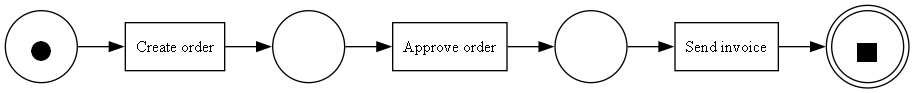

In [17]:
from IPython.display import Image, display

fig_path = os.path.join(OUTPUT_DIR, "fig_synth_petri_net.png")

if shutil.which("dot"):
    pm4py.save_vis_petri_net(net, im, fm, fig_path)
    print("Petri net saved :", fig_path)
else:
    # Fallback: save DFG instead (no Graphviz required)
    dfg, start_acts, end_acts = pm4py.discover_dfg(event_log)
    pm4py.save_vis_dfg(dfg, start_acts, end_acts, fig_path)
    print("Graphviz not found — DFG saved instead:", fig_path)

display(Image(fig_path))


## Extended Analysis

The sections below extend the basic pipeline with:
- Variant analysis
- Directly-Follows Graph (DFG)
- Conformance checking
- Performance analysis (throughput time, waiting time)


### Task 7 — Variant Analysis

A **variant** is a unique sequence of activity labels within a case.
This log has **one variant**:
- V1: Create order → Approve order → Send invoice (all 3 cases)

Since all three cases follow the same sequence, the process is **deterministic** —
the Inductive Miner will discover a simple linear Petri net with no branching or XOR choice.

In [20]:
variants = pm4py.get_variants(event_log)
print(f"Distinct variants: {len(variants)}")
print()
for variant, count in variants.items():
    n    = count if isinstance(count, int) else len(count)
    path = " -> ".join(variant) if isinstance(variant, tuple) else str(variant)
    print(f"  [{n} case(s)]  {path}")


Distinct variants: 1

  [3 case(s)]  Create order -> Approve order -> Send invoice


### Task 8 — Directly-Follows Graph (DFG)

The DFG records which activity pairs appear consecutively and how often.
All three cases follow the same sequence, so both arcs each have frequency 3:
- Create order → Approve order (freq: 3)
- Approve order → Send invoice  (freq: 3)

The DFG is the **input representation** the Inductive Miner uses internally
before constructing the Petri net.

Directly-follows pairs:
  Create order -> Approve order  (freq: 3)
  Approve order -> Send invoice  (freq: 3)

Start activities: {'Create order': 3}
End   activities: {'Send invoice': 3}

Saved: output\fig_synth_dfg.png


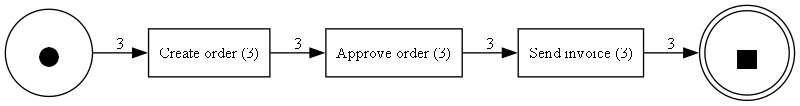

In [23]:
dfg, start_acts, end_acts = pm4py.discover_dfg(event_log)

print("Directly-follows pairs:")
for (a, b), freq in sorted(dfg.items(), key=lambda x: -x[1]):
    print(f"  {a} -> {b}  (freq: {freq})")

print("\nStart activities:", start_acts)
print("End   activities:", end_acts)

fig_dfg = os.path.join(OUTPUT_DIR, "fig_synth_dfg.png")
if shutil.which("dot"):
    pm4py.save_vis_dfg(dfg, start_acts, end_acts, fig_dfg)
    print("\nSaved:", fig_dfg)
    display(Image(fig_dfg))
else:
    print("\nGraphviz not found — DFG image skipped.")


### Task 9 — Conformance Checking: Token-Based Replay

Token-based replay fires tokens through the Petri net for each event in a trace.
A fitness of 1.0 means every trace can be replayed without missing or leftover tokens.

Since the model was discovered from this log, we expect a perfect fitness score.


In [25]:
fitness = pm4py.fitness_token_based_replay(event_log, net, im, fm)

print("=== Token-Based Replay ===")
print(f"Log fitness          : {fitness['log_fitness']:.4f}")
print(f"Average trace fitness: {fitness['average_trace_fitness']:.4f}")
print(f"Perfectly fitting    : {fitness['percentage_of_fitting_traces']:.1f}%")

if fitness["log_fitness"] >= 0.99:
    print("\nInterpretation: Perfect fit — model reproduces all observed traces.")
elif fitness["log_fitness"] >= 0.80:
    print("\nInterpretation: Good fit — minor deviations exist.")
else:
    print("\nInterpretation: Moderate — consider tuning the algorithm.")


=== Token-Based Replay ===
Log fitness          : 1.0000
Average trace fitness: 1.0000
Perfectly fitting    : 100.0%

Interpretation: Perfect fit — model reproduces all observed traces.


### Task 10 — Performance Analysis: Throughput Time

**Throughput time** = last event timestamp − first event timestamp per case.

All three cases follow the same activity sequence; small differences in duration
arise only from the different start times set during dataset construction:
- Case 1: 11:00 − 09:00 = **120 min**
- Case 2: 11:20 − 09:15 = **125 min**
- Case 3: 10:40 − 08:45 = **115 min**

The **coefficient of variation** (CV = std / mean) measures how consistent
case durations are. A low CV means all cases take approximately the same time.

In [28]:
tt = (
    df_toy.groupby("case:concept:name")["time:timestamp"].max()
  - df_toy.groupby("case:concept:name")["time:timestamp"].min()
)
tt_min = tt.dt.total_seconds() / 60

print("Throughput time per case:")
for cid, val in tt_min.items():
    print(f"  Case {cid}: {val:.0f} min")

print(f"\nMean   : {tt_min.mean():.1f} min")
print(f"Median : {tt_min.median():.1f} min")
print(f"Std    : {tt_min.std():.1f} min")
print(f"CV     : {tt_min.std()/tt_min.mean():.2f}")


Throughput time per case:
  Case 1: 120 min
  Case 2: 125 min
  Case 3: 115 min

Mean   : 120.0 min
Median : 120.0 min
Std    : 5.0 min
CV     : 0.04


### Task 11 — Performance Analysis: Waiting Time Between Activities

Breaking throughput down by activity transition shows **where time is spent**.
Expected averages:
- Create order → Approve order: mean ≈ 67 min
- Approve order → Send invoice: mean ≈ 53 min

In a real log, a consistently long wait before one activity suggests a **resource bottleneck**
at that step — e.g. a single approver handling many cases in a queue.

In [31]:
print("Waiting time between consecutive activities (minutes):\n")

wait_records = []
for case_id in sorted(df_toy["case:concept:name"].unique()):
    case_df = (df_toy[df_toy["case:concept:name"] == case_id]
               .sort_values("time:timestamp").reset_index(drop=True))
    print(f"Case {case_id}:")
    for i in range(1, len(case_df)):
        wait = (case_df.loc[i, "time:timestamp"] -
                case_df.loc[i-1, "time:timestamp"]).total_seconds() / 60
        arc  = (f"{case_df.loc[i-1,'concept:name']} -> "
                f"{case_df.loc[i,'concept:name']}")
        print(f"  {arc}: {wait:.0f} min")
        wait_records.append({"arc": arc, "wait_min": wait})
    print()

wait_df = pd.DataFrame(wait_records)
print("Average waiting time per transition:")
print(wait_df.groupby("arc")["wait_min"].mean().round(1).to_string())


Waiting time between consecutive activities (minutes):

Case 1:
  Create order -> Approve order: 60 min
  Approve order -> Send invoice: 60 min

Case 2:
  Create order -> Approve order: 75 min
  Approve order -> Send invoice: 50 min

Case 3:
  Create order -> Approve order: 65 min
  Approve order -> Send invoice: 50 min

Average waiting time per transition:
arc
Approve order -> Send invoice    53.3
Create order -> Approve order    66.7
